# Análise de Desempenho de Técnicas de Aprendizagem Automática em PTD

## Trabalho Prático 2 - Análise de Dados em Informática

O presente trabalho foi desenvolvido no âmbito da unidade curricular de **Análise de Dados em Informática**, tendo como objetivo a análise de dados relativos a **Postos de Transformação de Distribuição (PTD)**, **iluminação pública** e **capacidade disponível na rede elétrica**.

No contexto atual de **transição energética** e crescente adoção da **mobilidade elétrica**, torna-se essencial avaliar a capacidade das infraestruturas elétricas existentes para suportar novas cargas. A iluminação pública representa uma componente significativa do consumo energético municipal, sendo a sua modernização, nomeadamente através da substituição por **tecnologia LED**, uma oportunidade para aumentar a **eficiência energética** e libertar capacidade na rede elétrica.

Este estudo centra-se na análise da relação entre a **eficiência energética da iluminação pública** e a **disponibilidade de potência nos PTD**, com o objetivo de avaliar a **viabilidade técnica** da instalação de pontos de carregamento para veículos elétricos, sem comprometer a **estabilidade** e **fiabilidade** da rede.

Ao longo deste trabalho será realizada uma **análise exploratória dos dados**, seguida de etapas de **pré-processamento** e desenvolvimento de **modelos de aprendizagem automática** para tarefas de **regressão** e **classificação**. Estes modelos serão posteriormente avaliados e comparados com base em **métricas apropriadas**, de forma a identificar as abordagens mais adequadas ao problema em estudo.


## 4.1 Análise Exploratória de Dados

A **análise exploratória de dados** (*Exploratory Data Analysis* - **EDA**) constitui a primeira etapa prática do trabalho, sendo fundamental para compreender a **estrutura**, **qualidade** e **comportamento geral** do dataset antes da aplicação de modelos de aprendizagem automática.

Nesta fase, procede-se inicialmente ao **carregamento do dataset** e à análise do seu **sumário estatístico**, incluindo a verificação da dimensão, identificação das variáveis e dos respetivos tipos de dados. De seguida, é realizada uma **exploração visual dos dados** através de gráficos apropriados, com o objetivo de analisar distribuições, identificar padrões, detetar valores extremos e compreender relações entre variáveis.

Posteriormente, é efetuada uma **análise da qualidade dos dados**, incluindo a identificação de **valores omissos**, **duplicados**, **variáveis constantes**, formatos inconsistentes e possíveis anomalias. Esta etapa permite garantir a fiabilidade dos dados utilizados nas fases seguintes.

Com base nesta análise, é realizado o **pré-processamento dos dados**, que inclui o tratamento de valores em falta, a transformação de variáveis categóricas em formato numérico e a **normalização** ou **standardização** das variáveis, sempre que necessário para os algoritmos de aprendizagem automática considerados.

Adicionalmente, é efetuada a **seleção de variáveis relevantes**, excluindo atributos que funcionem como identificadores, que sejam redundantes ou que estejam diretamente relacionados com a variável alvo, de forma a preservar a capacidade de generalização dos modelos.

Por fim, é construído um **dataset final de modelação**, resultante das etapas anteriores, que servirá de base para o desenvolvimento dos modelos de **regressão** e **classificação**.

Esta fase assume um papel crítico no desempenho dos modelos, uma vez que a **qualidade dos dados** e a **seleção adequada das variáveis** influenciam diretamente a capacidade preditiva e a robustez dos resultados obtidos.


### 4.1.1 Carregamento, dimensão e sumário inicial dos dados

Nesta etapa inicial procede-se ao **carregamento do ficheiro de dados** e à realização de uma inspeção preliminar da sua estrutura. O objetivo consiste em garantir que o dataset foi corretamente importado e em obter uma primeira compreensão da informação disponível.

Para tal, são analisados aspetos como a **dimensão do dataset**, a visualização das primeiras observações, os **nomes das variáveis**, os respetivos **tipos de dados** e um conjunto de **estatísticas descritivas iniciais**.

Esta análise permite identificar características gerais dos dados e constitui a base para as etapas subsequentes de **exploração** e **pré-processamento**, nas quais serão aplicadas transformações e tratamentos mais detalhados com vista à modelação.


In [1]:
# Bibliotecas utilizadas na fase de carregamento e manipulação de dados
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300

# Paleta visual única para manter consistência em todos os gráficos
COR_PRINCIPAL = "#2E86AB"
COR_SECUNDARIA = "#A23B72"
PALETA_CORRELACAO = "vlag"


# Definição do caminho do ficheiro de dados.
# São consideradas duas localizações possíveis, de forma a garantir a execução do notebook
# tanto a partir da pasta 'src' como da raiz do projeto.
possible_paths = [
    Path("..") / "data" / "PTD_level_dataset.xlsx",
    Path("data") / "PTD_level_dataset.xlsx"
]

DATA_PATH = next((path for path in possible_paths if path.exists()), None)

# Validação da existência do ficheiro
if DATA_PATH is None:
    raise FileNotFoundError(
        "O ficheiro 'PTD_level_dataset.xlsx' não foi encontrado na pasta 'data'."
    )

# Leitura do ficheiro Excel para um DataFrame pandas
# Nesta fase, os dados são mantidos no seu formato original, sem qualquer tipo de transformação
df = pd.read_excel(DATA_PATH)

# Pasta onde serão guardados automaticamente os gráficos produzidos no notebook
PROJECT_DIR = DATA_PATH.parent.parent
GRAPHICS_DIR = PROJECT_DIR / "graficos"
GRAPHICS_DIR.mkdir(exist_ok=True)


def guardar_grafico(fig, nome_ficheiro):
    """Guarda a figura na pasta graficos com margens ajustadas."""
    fig.savefig(GRAPHICS_DIR / nome_ficheiro, bbox_inches="tight", facecolor="white")

# Verificação básica do carregamento
print(f"Dataset carregado com sucesso a partir de: {DATA_PATH}")


Dataset carregado com sucesso a partir de: ..\data\PTD_level_dataset.xlsx


In [2]:
# Dimensão do dataset: número de registos (linhas) e variáveis (colunas)
n_linhas, n_colunas = df.shape
print(f"Dimensão do dataset: {n_linhas} linhas e {n_colunas} colunas")


# Visualização das primeiras observações
# Permite validar a correta leitura do ficheiro e obter uma visão geral dos dados
display(df.head())


# Identificação das variáveis e respetivos tipos de dados
# Útil para distinguir entre variáveis numéricas e categóricas
variaveis = pd.DataFrame({
    "Variável": df.columns,
    "Tipo de dados": df.dtypes.astype(str).values
})
display(variaveis)


# Sumário estrutural do dataset
# Inclui número de valores não nulos e tipos de dados
print("\nInformação geral do dataset:")
df.info()


# Estatísticas descritivas das variáveis numéricas
print("\nEstatísticas descritivas (variáveis numéricas):")
display(df.describe().T)


# Estatísticas descritivas das variáveis categóricas
print("\nEstatísticas descritivas (variáveis categóricas):")
display(df.describe(include=["string", "object"]).T)


# Verificação de valores em falta (muito importante para o pré-processamento)
missing_values = pd.DataFrame({
    "Valores em falta": df.isnull().sum(),
    "Percentagem (%)": (df.isnull().mean() * 100).round(2)
}).sort_values("Valores em falta", ascending=False)

display(missing_values[missing_values["Valores em falta"] > 0])


Dimensão do dataset: 72027 linhas e 32 colunas


,Distrito,Concelho,CodDistritoConcelho,Código de Instalação,Coordenadas Geográficas,Potência instalada [kVA],Tipo Construtivo,Cap_PTD_kVA,Pot_Contratada_kVA,N_Clientes,...,IP_Inef_per_PTD,Ganho_LED_PTD,D_PTD_LED,Cap_per_Cliente,PContratada_per_Cliente,Geracao_per_Cliente,Clientes_Produtores_Ratio,Nível de Utilização [%],Util_Decimal,PFolga_PTD
0,Porto,Marco de Canaveses,1307,1307D2012500,"41.1849010463209, -8.14785254356171",400,Cabine pré-fabricada,400,105269.0,131,...,2.671833,1.736691,65.816691,3.053435,803.580153,NaN,0.152672,60%-79%,0.79,77.28
1,Porto,Marco de Canaveses,1307,1307D2012900,"41.0869934226954, -8.24673374651495",250,Cabine baixa integrada em edifício,250,77520.0,115,...,2.671833,1.736691,36.836691,2.173913,674.086957,NaN,0.173913,60%-79%,0.79,48.30
2,Porto,Marco de Canaveses,1307,1307D2013100,"41.1129221154249, -8.21276525945275",250,Cabine alta,250,110419.0,176,...,2.671833,1.736691,36.836691,1.420455,627.380682,NaN,0.113636,60%-79%,0.79,48.30
3,Porto,Marco de Canaveses,1307,1307D2013800,"41.1329530486552, -8.13563404382479",50,Aéreo - AS,50,23807.0,36,...,2.671833,1.736691,-11.463309,1.388889,661.305556,NaN,0.555556,+100%,1.00,0.00
4,Porto,Marco de Canaveses,1307,1307D2015100,"41.1228444565974, -8.11290068900831",250,Aéreo - AI,250,60851.0,94,...,2.671833,1.736691,174.836691,2.659574,647.351064,NaN,0.212766,0%-19%,0.19,186.30


,Variável,Tipo de dados
0,Distrito,str
1,Concelho,str
2,CodDistritoConcelho,int64
3,Código de Instalação,str
4,Coordenadas Geográficas,str
5,Potência instalada [kVA],int64
6,Tipo Construtivo,str
7,Cap_PTD_kVA,int64
8,Pot_Contratada_kVA,float64
9,N_Clientes,int64



Informação geral do dataset:
<class 'pandas.DataFrame'>
RangeIndex: 72027 entries, 0 to 72026
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Distrito                   72027 non-null  str    
 1   Concelho                   72027 non-null  str    
 2   CodDistritoConcelho        72027 non-null  int64  
 3   Código de Instalação       72027 non-null  str    
 4   Coordenadas Geográficas    72027 non-null  str    
 5   Potência instalada [kVA]   72027 non-null  int64  
 6   Tipo Construtivo           72027 non-null  str    
 7   Cap_PTD_kVA                72027 non-null  int64  
 8   Pot_Contratada_kVA         50847 non-null  float64
 9   N_Clientes                 72027 non-null  int64  
 10  Pot_Geracao_kW             1836 non-null   float64
 11  N_Clientes_Produtores      72027 non-null  int64  
 12  P_IP_Total                 72027 non-null  float64
 13  P_IP_Inef                  

,count,mean,std,min,25%,50%,75%,max
CodDistritoConcelho,72027.0,989.432671,4.939913e+02,101.000000,603.000000,1106.000000,1317.000000,1824.000000
Potência instalada [kVA],72027.0,302.798825,2.944445e+02,0.000000,100.000000,250.000000,400.000000,8000.000000
Cap_PTD_kVA,72027.0,302.798825,2.944445e+02,0.000000,100.000000,250.000000,400.000000,8000.000000
Pot_Contratada_kVA,50847.0,80941.484060,6.714603e+04,5456.000000,34035.500000,60886.000000,106720.000000,804687.000000
N_Clientes,72027.0,94.698002,1.100551e+02,20.000000,20.000000,54.000000,124.000000,1438.000000
Pot_Geracao_kW,1836.0,6216.724401,2.876378e+03,1622.000000,4271.750000,5574.500000,7393.500000,22032.000000
N_Clientes_Produtores,72027.0,20.203479,2.017686e+00,20.000000,20.000000,20.000000,20.000000,106.000000
P_IP_Total,72027.0,1381.490215,1.723711e+03,23.218600,382.569000,842.179701,1766.391301,9065.655300
P_IP_Inef,72027.0,463.290614,7.080096e+02,0.000000,28.985000,137.720000,625.790000,3494.920000
Rate_Ineficiencia,72027.0,0.280694,2.403671e-01,0.000000,0.064209,0.229231,0.447381,0.983568



Estatísticas descritivas (variáveis categóricas):


,count,unique,top,freq
Distrito,72027,18,Porto,9028
Concelho,72027,278,Lisboa,2278
Código de Instalação,72027,72027,1307D2012500,1
Coordenadas Geográficas,72027,72027,"41.1849010463209, -8.14785254356171",1
Tipo Construtivo,72027,10,Aéreo - AS,18805
Nível de Utilização [%],72027,7,20%-39%,20892


,Valores em falta,Percentagem (%)
Pot_Geracao_kW,70191,97.45
Geracao_per_Cliente,70191,97.45
PContratada_per_Cliente,21180,29.41
Pot_Contratada_kVA,21180,29.41
D_PTD_LED,3064,4.25
D_PTD,3064,4.25
Util_Decimal,3064,4.25
PFolga_PTD,3064,4.25


A análise inicial confirma que o dataset foi carregado corretamente, contendo **72.027 registos** e **32 variáveis**, o que constitui uma base de dados de dimensão relevante para a aplicação de técnicas de aprendizagem automática.

Verifica-se a presença de **variáveis numéricas**, como `Cap_PTD_kVA`, `N_Clientes` e `PFolga_PTD`, e **variáveis categóricas**, como `Distrito`, `Concelho` e `Tipo Construtivo`. Algumas destas variáveis categóricas apresentam um número elevado de categorias, por exemplo **278 concelhos**, o que poderá exigir transformação adequada na fase de pré-processamento.

A análise dos **valores em falta** revela situações distintas: variáveis como `Pot_Geracao_kW` e `Geracao_per_Cliente` apresentam cerca de **97% de valores omissos**, o que poderá comprometer a sua utilidade, enquanto outras, como `PContratada_per_Cliente`, apresentam cerca de **29% de omissões**. Já variáveis como `Util_Decimal` e `PFolga_PTD` apresentam apenas cerca de **4% de valores em falta**, sendo mais facilmente tratáveis.

Observa-se ainda que algumas variáveis, como `Código de Instalação` e `Coordenadas Geográficas`, apresentam valores praticamente únicos por registo, funcionando essencialmente como **identificadores**, podendo não contribuir diretamente para a capacidade preditiva dos modelos.

Com base nesta análise, conclui-se que será necessário **tratar cuidadosamente os valores omissos**, **avaliar a relevância das variáveis com elevada percentagem de ausência** e **preparar adequadamente os dados** para as fases seguintes de modelação.


### 4.1.2 Exploração visual dos dados

Após o **carregamento** e **análise preliminar** do dataset, procede-se à **exploração visual dos dados**, com o objetivo de aprofundar a compreensão da **distribuição das variáveis**, identificar possíveis **valores extremos** e analisar **padrões** e **relações relevantes** para as fases de modelação.

Esta etapa assume particular importância no contexto do problema em estudo, uma vez que os dados incluem variáveis relacionadas com a **capacidade dos Postos de Transformação de Distribuição (PTD)**, a **utilização da rede elétrica**, a **eficiência da iluminação pública** e a **folga de potência disponível**. Assim, é dada especial atenção à variável **`PFolga_PTD`**, considerada como **variável alvo na tarefa de regressão**, bem como à variável **`Util_Decimal`**, relevante para a futura tarefa de **classificação**.

Para este efeito, são utilizados diferentes tipos de representações gráficas, nomeadamente **gráficos de distribuição**, **boxplots**, **gráficos de barras**, **mapas de correlação** e **gráficos de dispersão**. Estas visualizações permitem não só identificar **padrões** e **tendências** nos dados, mas também fundamentar decisões posteriores relacionadas com o **tratamento de valores omissos**, **normalização**, **identificação de outliers** e **seleção de variáveis relevantes** para os modelos de aprendizagem automática.


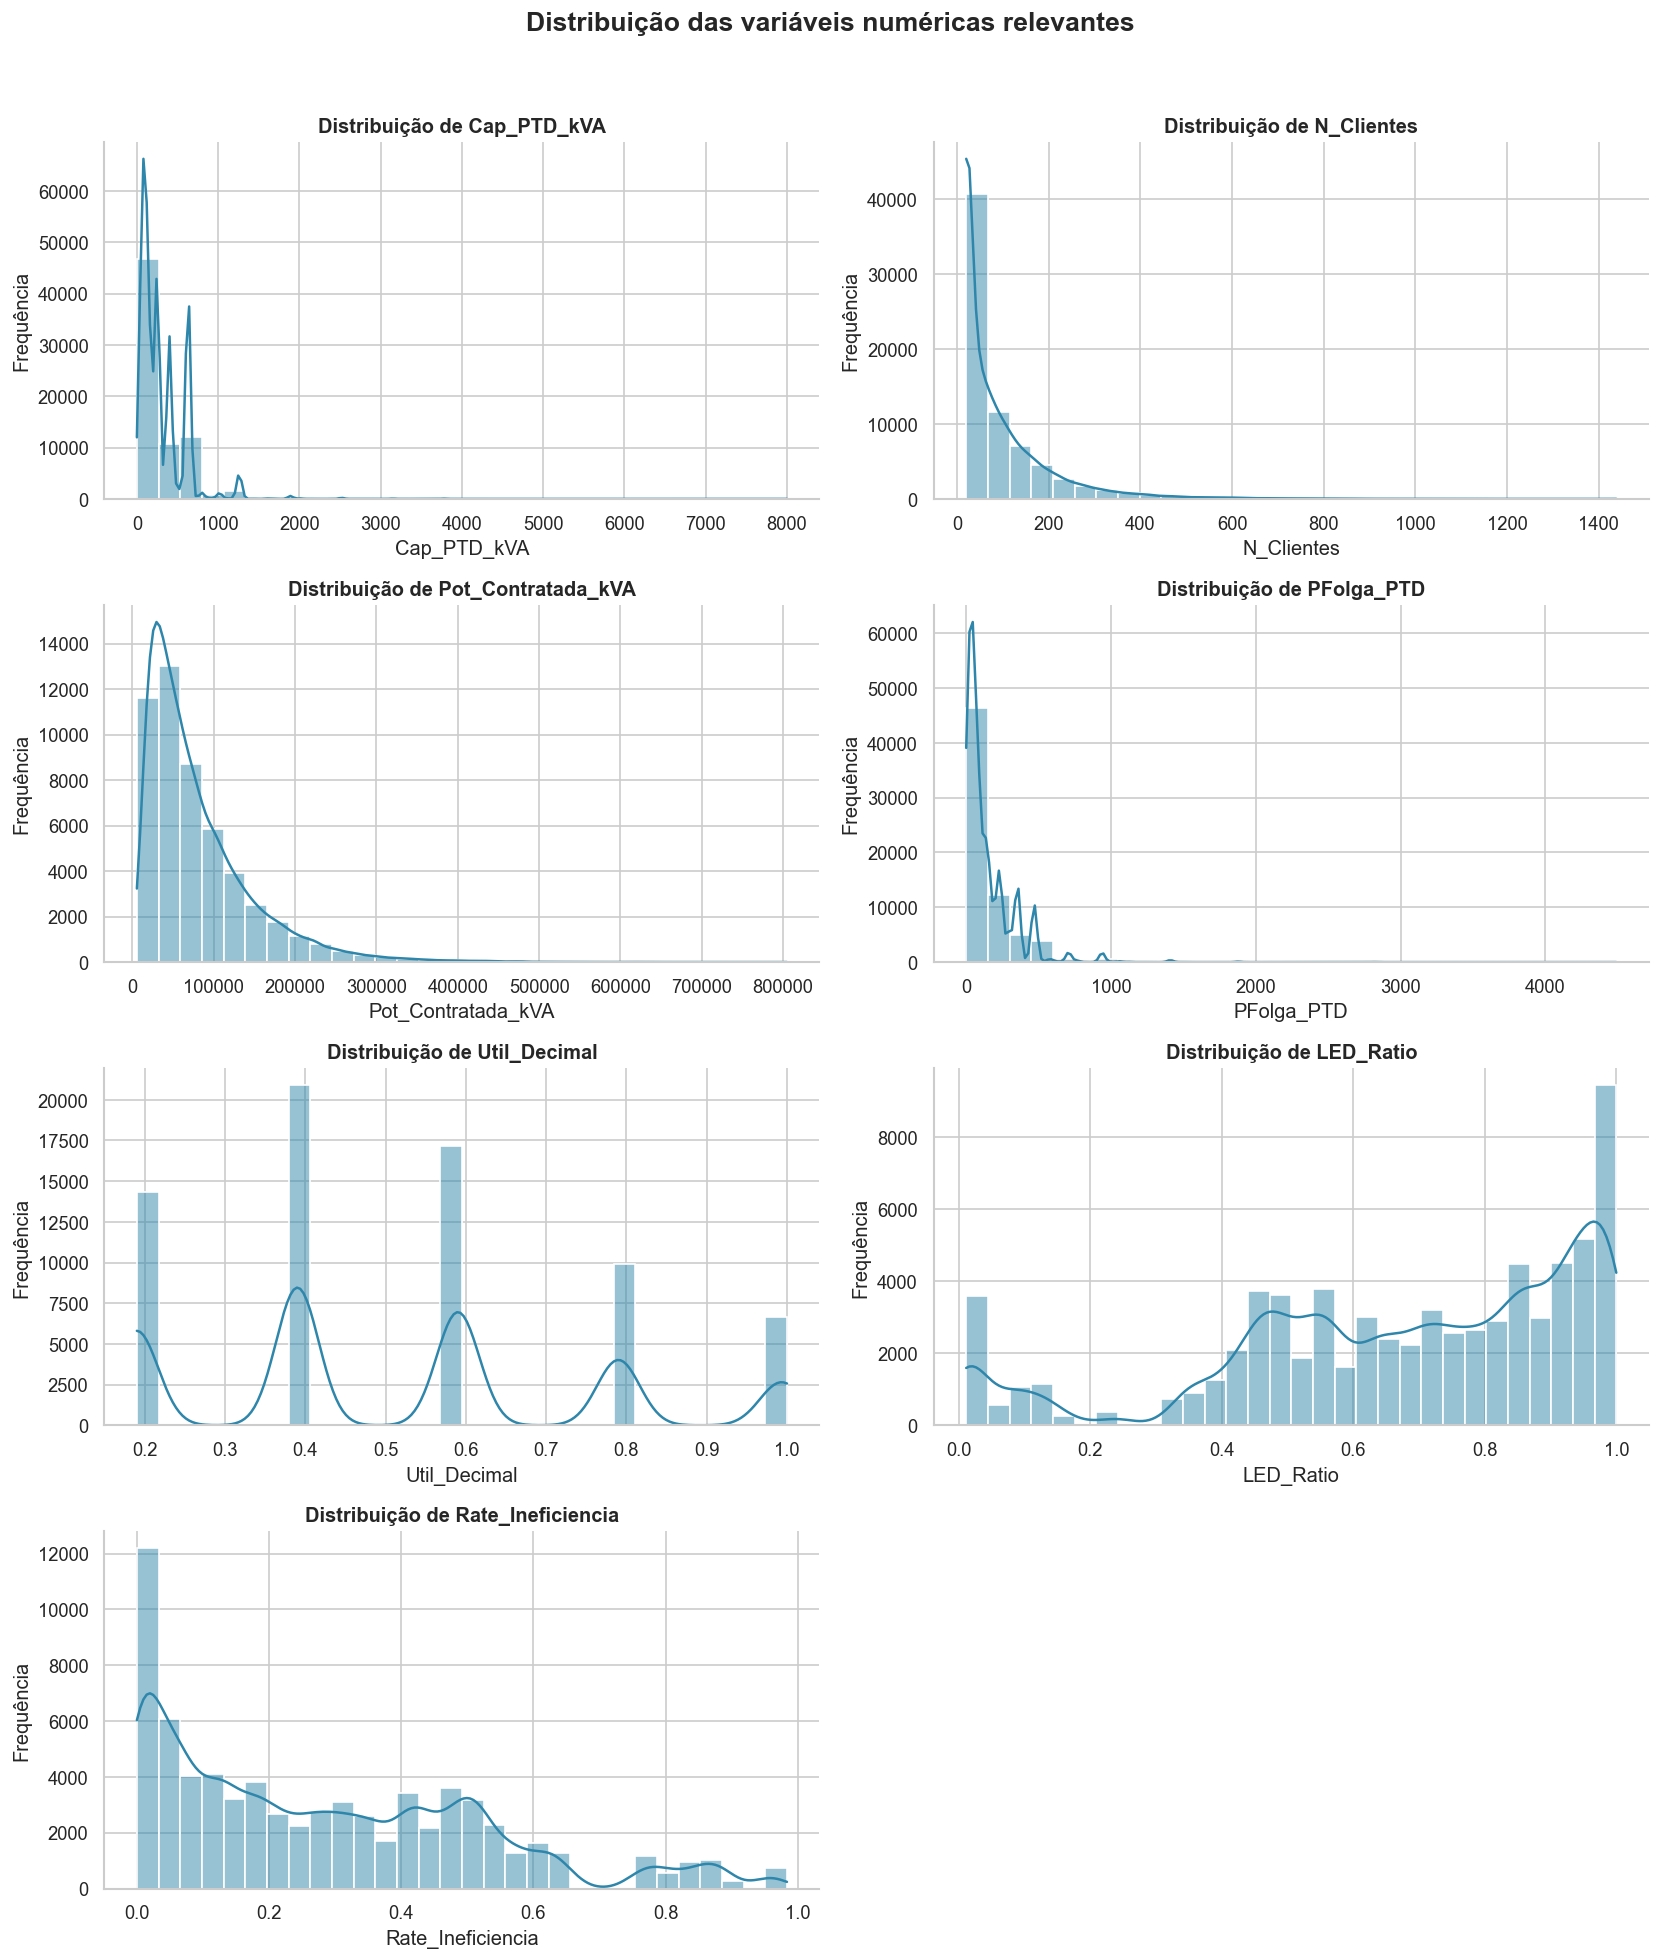

In [3]:
# Variáveis numéricas consideradas mais relevantes para a análise visual inicial
numeric_vars = [
    "Cap_PTD_kVA",
    "N_Clientes",
    "Pot_Contratada_kVA",
    "PFolga_PTD",
    "Util_Decimal",
    "LED_Ratio",
    "Rate_Ineficiencia"
]

# Apenas são usadas variáveis que existem no dataset, evitando erros caso algum nome não esteja disponível
numeric_vars = [var for var in numeric_vars if var in df.columns]

n_cols = 2
n_rows = int(np.ceil(len(numeric_vars) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
fig.suptitle("Distribuição das variáveis numéricas relevantes", fontsize=16, fontweight="bold", y=1.02)
axes = axes.flatten()

for ax, var in zip(axes, numeric_vars):
    sns.histplot(df[var].dropna(), kde=True, bins=30, color=COR_PRINCIPAL, edgecolor="white", ax=ax)
    ax.set_title(f"Distribuição de {var}", fontweight="bold")
    ax.set_xlabel(var)
    ax.set_ylabel("Frequência")
    sns.despine(ax=ax)

# Remove eixos vazios quando o número de variáveis não ocupa toda a grelha
for ax in axes[len(numeric_vars):]:
    ax.set_visible(False)

plt.tight_layout()
guardar_grafico(fig, "distribuicoes_variaveis_numericas.png")
plt.show()


A análise das **distribuições das variáveis numéricas** evidencia comportamentos distintos entre os atributos selecionados.

As variáveis **`Cap_PTD_kVA`**, **`N_Clientes`**, **`Pot_Contratada_kVA`** e **`PFolga_PTD`** apresentam **distribuições assimétricas à direita**, com grande concentração de observações em valores mais baixos e presença de **valores extremos**. Este comportamento indica que a maioria dos PTD possui capacidades, número de clientes, potência contratada e folga de potência relativamente reduzidos, existindo apenas um conjunto menor de PTD com valores muito superiores.

A variável **`PFolga_PTD`**, sendo a **variável alvo da tarefa de regressão**, apresenta uma distribuição bastante concentrada nos valores mais baixos, mas com **cauda longa**. Esta característica poderá influenciar o desempenho dos modelos, especialmente dos modelos sensíveis a **outliers**.

A variável **`Util_Decimal`** apresenta valores concentrados em **intervalos discretos**, sugerindo que resulta de uma categorização ou de níveis de utilização pré-definidos. Este comportamento é coerente com a sua futura utilização na tarefa de **classificação**.

Relativamente às variáveis associadas à **iluminação pública**, observa-se que **`LED_Ratio`** apresenta maior concentração em valores elevados, indicando que muitos concelhos já possuem uma percentagem significativa de **iluminação LED**. Por outro lado, **`Rate_Ineficiencia`** apresenta maior concentração em valores baixos, embora com alguma dispersão ao longo do intervalo.

De forma geral, estas distribuições indicam a necessidade de considerar **normalização** ou **standardização** antes da aplicação de modelos sensíveis à escala, como **SVM**, **KNN** e **redes neuronais**, bem como uma análise posterior de **outliers**.


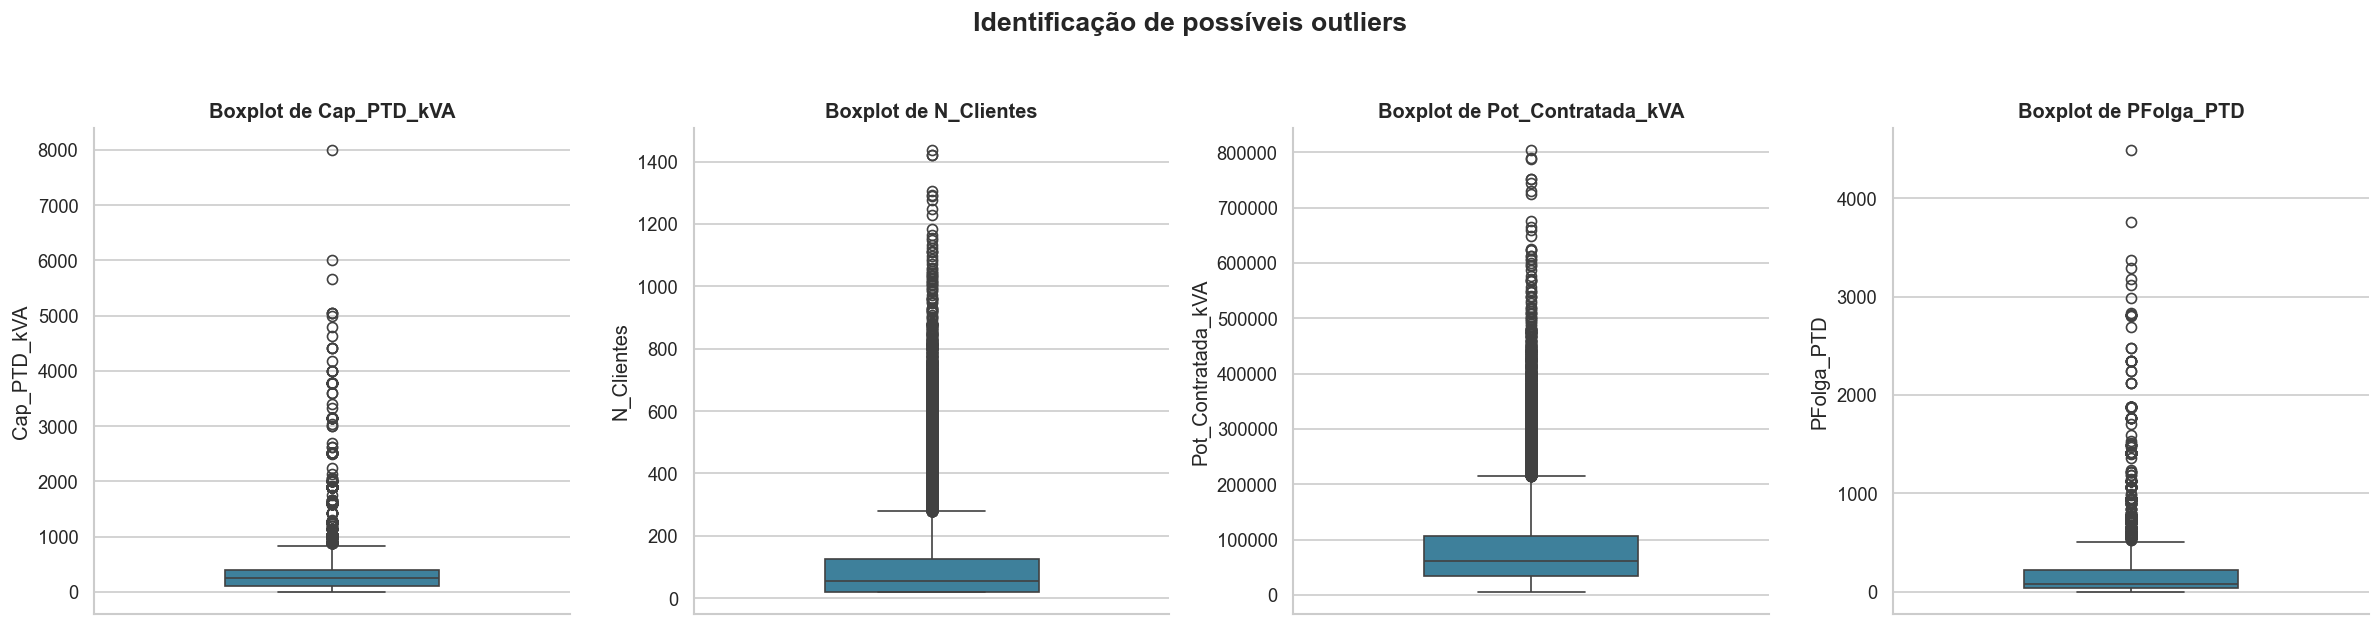

In [4]:
# Variáveis numéricas onde é particularmente útil procurar valores extremos
boxplot_vars = [
    "Cap_PTD_kVA",
    "N_Clientes",
    "Pot_Contratada_kVA",
    "PFolga_PTD"
]

boxplot_vars = [var for var in boxplot_vars if var in df.columns]

fig, axes = plt.subplots(1, len(boxplot_vars), figsize=(5 * len(boxplot_vars), 5))
fig.suptitle("Identificação de possíveis outliers", fontsize=16, fontweight="bold", y=1.04)

if len(boxplot_vars) == 1:
    axes = [axes]

for ax, var in zip(axes, boxplot_vars):
    sns.boxplot(y=df[var].dropna(), color=COR_PRINCIPAL, width=0.45, ax=ax)
    ax.set_title(f"Boxplot de {var}", fontweight="bold")
    ax.set_ylabel(var)
    sns.despine(ax=ax)

plt.tight_layout()
guardar_grafico(fig, "boxplots_outliers_variaveis_numericas.png")
plt.show()


Os **boxplots** confirmam a presença de **valores extremos** nas principais variáveis numéricas analisadas.

Nas variáveis **`Cap_PTD_kVA`**, **`N_Clientes`** e **`Pot_Contratada_kVA`**, observa-se que a maioria dos registos se concentra em valores relativamente baixos, enquanto existem vários PTD com valores bastante superiores à distribuição central. Este comportamento é coerente com os histogramas analisados anteriormente e indica uma **forte assimetria à direita**.

A variável **`PFolga_PTD`**, sendo a **variável alvo da regressão**, também apresenta um número considerável de **valores extremos**. Isto sugere que alguns PTD possuem uma folga de potência muito superior à maioria, podendo influenciar o treino dos modelos e as métricas de erro.

Assim, estes resultados reforçam a necessidade de avaliar o impacto dos **outliers** no **pré-processamento** e na **modelação**. No entanto, estes valores não devem ser removidos automaticamente, uma vez que podem representar PTD reais com maior capacidade instalada ou menor nível de utilização.


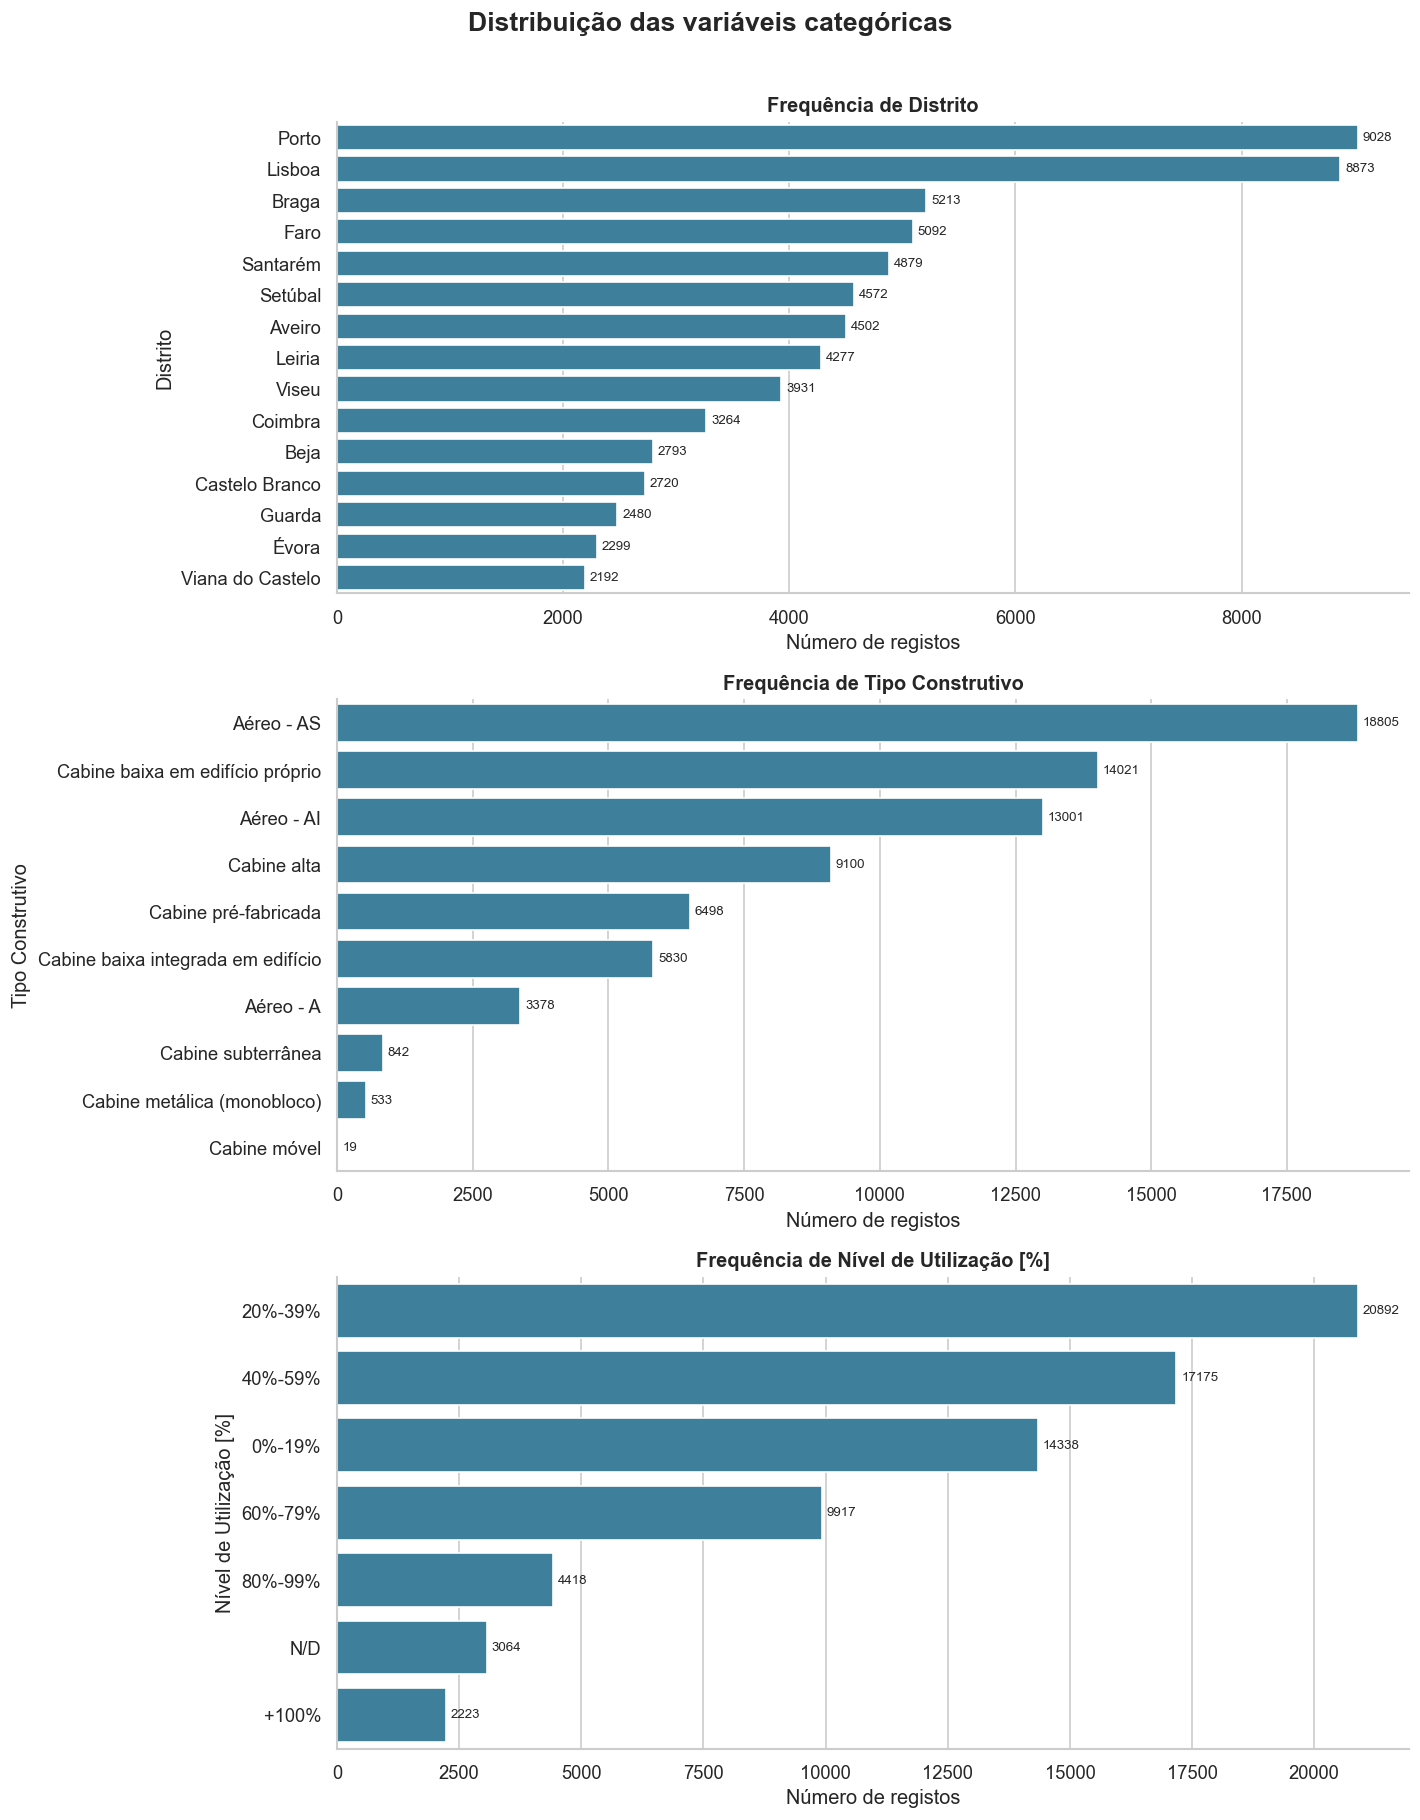

In [5]:
# Variáveis categóricas relevantes para perceber a composição do dataset
categorical_vars = [
    "Distrito",
    "Tipo Construtivo",
    "Nível de Utilização [%]"
]

categorical_vars = [var for var in categorical_vars if var in df.columns]

fig, axes = plt.subplots(len(categorical_vars), 1, figsize=(12, 5 * len(categorical_vars)))
fig.suptitle("Distribuição das variáveis categóricas", fontsize=16, fontweight="bold", y=1.01)

if len(categorical_vars) == 1:
    axes = [axes]

for ax, var in zip(axes, categorical_vars):
    counts = df[var].dropna().value_counts()
    
    # Para Distrito, mostram-se apenas os 15 mais frequentes para manter o gráfico legível
    if var == "Distrito":
        counts = counts.head(15)
    
    sns.barplot(x=counts.values, y=counts.index, color=COR_PRINCIPAL, ax=ax)
    ax.set_title(f"Frequência de {var}", fontweight="bold")
    ax.set_xlabel("Número de registos")
    ax.set_ylabel(var)
    ax.bar_label(ax.containers[0], padding=3, fontsize=8)
    sns.despine(ax=ax)

plt.tight_layout()
guardar_grafico(fig, "barras_variaveis_categoricas.png")
plt.show()


Os **gráficos de barras** permitem analisar a distribuição das **variáveis categóricas** e compreender a composição do dataset.

Relativamente à variável **`Distrito`**, observa-se uma maior concentração de registos em zonas como **Porto** e **Lisboa**, indicando uma maior representatividade destas regiões no dataset. Esta diferença pode influenciar os modelos, especialmente se existirem padrões regionais associados à utilização da rede ou à capacidade dos PTD.

Na variável **`Tipo Construtivo`**, verifica-se que os tipos **"Aéreo - AS"** e **"Cabine baixa em edifício próprio"** são os mais frequentes, enquanto outros tipos apresentam uma representatividade bastante reduzida. Esta desigualdade pode dificultar a aprendizagem de padrões para categorias menos representadas.

Por fim, a variável **`Nível de Utilização [%]`** mostra que a maioria dos PTD se encontra em níveis intermédios de utilização (**20%-39%** e **40%-59%**), sendo menos frequentes situações de utilização muito elevada. Este comportamento é relevante para a tarefa de **classificação**, pois indica uma **distribuição desequilibrada entre classes**.

De forma geral, estas distribuições sugerem a necessidade de considerar o impacto de **classes desbalanceadas** e avaliar a forma como as **variáveis categóricas** serão codificadas na fase de **pré-processamento**.


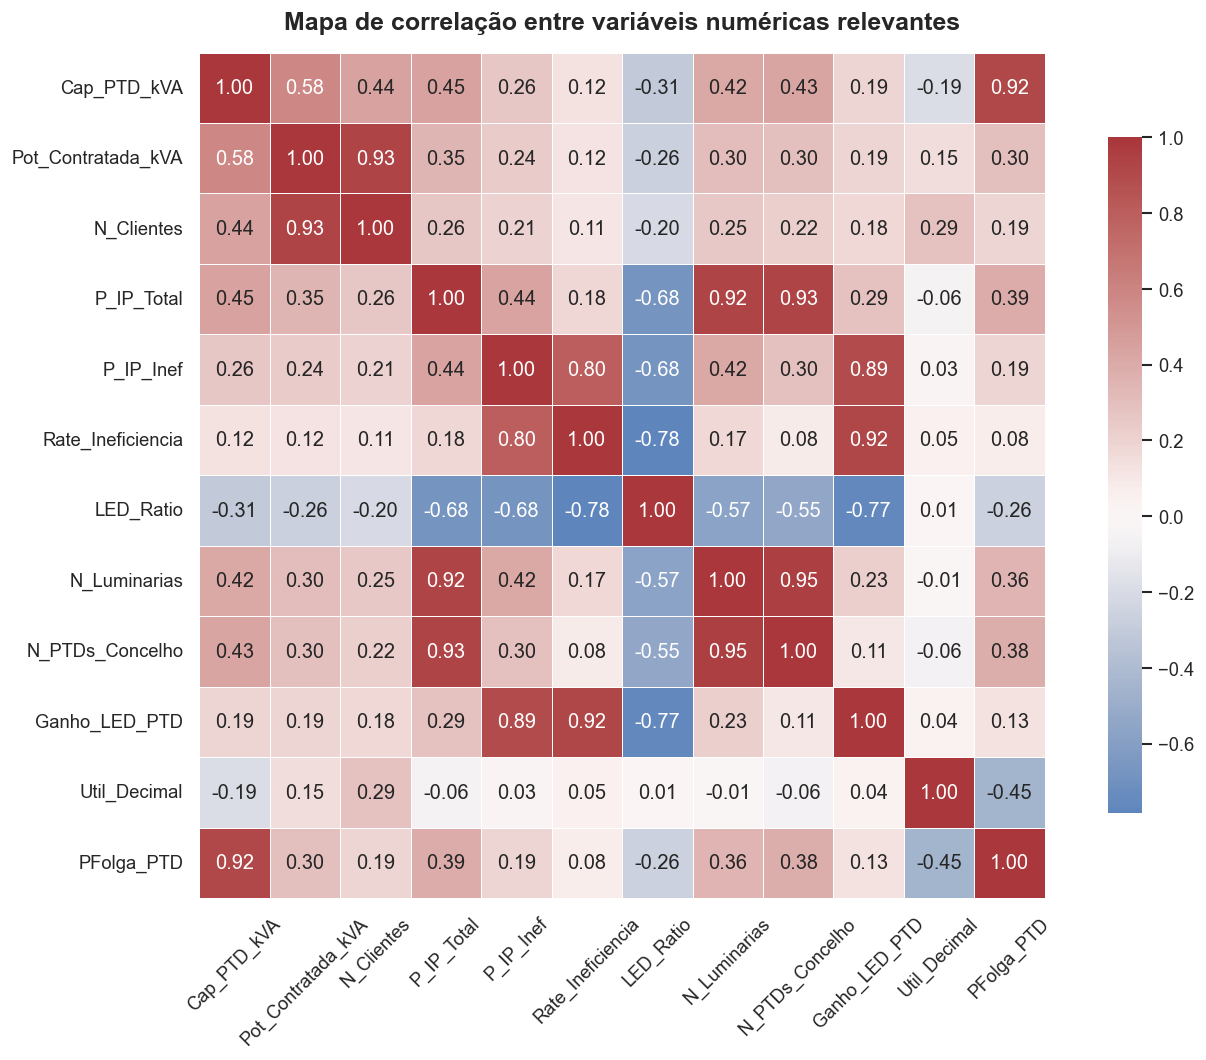

,Correlação com PFolga_PTD
Cap_PTD_kVA,0.915892
Util_Decimal,-0.452051
P_IP_Total,0.388398
N_PTDs_Concelho,0.383962
N_Luminarias,0.357481
Pot_Contratada_kVA,0.302577
LED_Ratio,-0.257265
N_Clientes,0.188011
P_IP_Inef,0.187407
Ganho_LED_PTD,0.129458


In [6]:
# Conjunto de variáveis numéricas usado para analisar relações lineares iniciais
corr_vars = [
    "Cap_PTD_kVA",
    "Pot_Contratada_kVA",
    "N_Clientes",
    "P_IP_Total",
    "P_IP_Inef",
    "Rate_Ineficiencia",
    "LED_Ratio",
    "N_Luminarias",
    "N_PTDs_Concelho",
    "Ganho_LED_PTD",
    "Util_Decimal",
    "PFolga_PTD"
]

corr_vars = [var for var in corr_vars if var in df.columns]
corr_matrix = df[corr_vars].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap=PALETA_CORRELACAO,
    center=0,
    square=True,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.8},
    ax=ax
)
ax.set_title("Mapa de correlação entre variáveis numéricas relevantes", fontsize=15, fontweight="bold", pad=14)
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
guardar_grafico(fig, "heatmap_correlacao_variaveis_numericas.png")
plt.show()

# Correlações ordenadas com a variável alvo da regressão
if "PFolga_PTD" in corr_matrix.columns:
    correlacoes_alvo = corr_matrix["PFolga_PTD"].drop("PFolga_PTD").sort_values(key=abs, ascending=False)
    display(correlacoes_alvo.to_frame("Correlação com PFolga_PTD"))


A análise das **correlações** com a variável alvo **`PFolga_PTD`** permite identificar de forma mais clara quais os fatores com maior influência na folga de potência.

Destaca-se uma **forte correlação positiva com `Cap_PTD_kVA` (≈ 0.92)**, confirmando que a capacidade instalada do PTD é o principal determinante da folga disponível. Esta relação é consistente com o funcionamento esperado da rede elétrica.

Observa-se também uma **correlação negativa moderada com `Util_Decimal` (≈ -0.45)**, indicando que níveis mais elevados de utilização da rede estão associados a menor folga de potência.

Adicionalmente, variáveis como **`P_IP_Total`**, **`N_PTDs_Concelho`** e **`N_Luminarias`** apresentam correlações positivas moderadas (≈ 0.35–0.39), sugerindo que a dimensão da infraestrutura elétrica e da iluminação pública tem impacto na disponibilidade de potência.

Por outro lado, variáveis como **`LED_Ratio`** apresentam correlação negativa (≈ -0.26), o que pode indicar que uma maior eficiência energética está associada a uma redistribuição da carga na rede.

De forma geral, estas correlações permitem identificar variáveis com maior **potencial preditivo** para a modelação da **`PFolga_PTD`**, bem como suportar decisões futuras de **seleção de variáveis** e **redução de redundância entre atributos**.


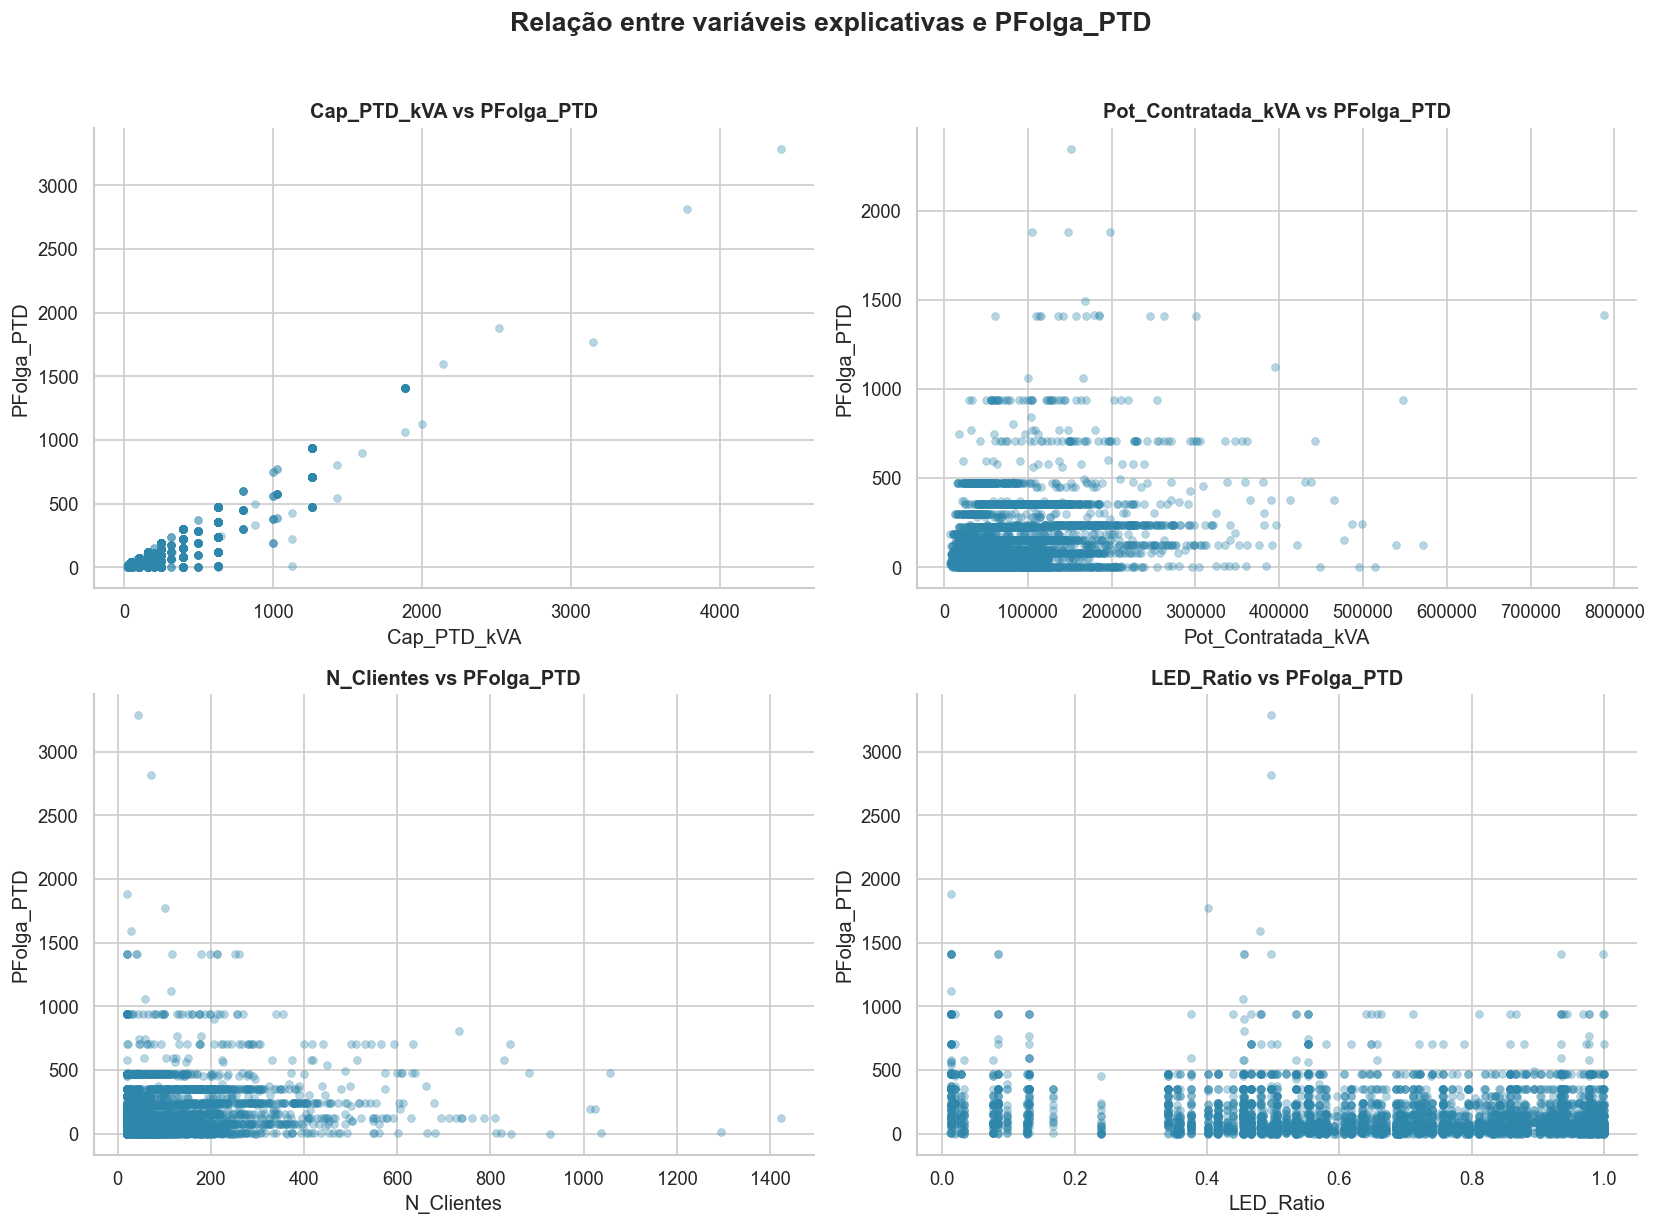

In [7]:
# Relações entre variáveis explicativas e a variável alvo da regressão
target = "PFolga_PTD"
scatter_vars = [
    "Cap_PTD_kVA",
    "Pot_Contratada_kVA",
    "N_Clientes",
    "LED_Ratio"
]

scatter_vars = [var for var in scatter_vars if var in df.columns and target in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Relação entre variáveis explicativas e PFolga_PTD", fontsize=16, fontweight="bold", y=1.02)
axes = axes.flatten()

for ax, var in zip(axes, scatter_vars):
    plot_data = df[[var, target]].dropna()
    
    # Usa-se uma amostra para manter os gráficos leves e legíveis num dataset com muitos registos
    if len(plot_data) > 5000:
        plot_data = plot_data.sample(n=5000, random_state=42)
    
    sns.scatterplot(data=plot_data, x=var, y=target, alpha=0.35, s=22, color=COR_PRINCIPAL, edgecolor=None, ax=ax)
    ax.set_title(f"{var} vs {target}", fontweight="bold")
    ax.set_xlabel(var)
    ax.set_ylabel(target)
    sns.despine(ax=ax)

for ax in axes[len(scatter_vars):]:
    ax.set_visible(False)

plt.tight_layout()
guardar_grafico(fig, "scatter_relacoes_com_pfolga_ptd.png")
plt.show()


Os **gráficos de dispersão** permitem analisar a relação entre algumas **variáveis explicativas** e a variável alvo **`PFolga_PTD`**.

Observa-se uma **relação claramente positiva entre `Cap_PTD_kVA` e `PFolga_PTD`**, indicando que PTD com maior capacidade instalada tendem a apresentar maior folga de potência. Esta relação é aproximadamente linear e confirma os resultados obtidos na análise de correlação.

No caso da variável **`Pot_Contratada_kVA`**, a relação com **`PFolga_PTD`** é menos evidente e apresenta maior dispersão. Embora existam alguns valores elevados de folga associados a maiores níveis de potência contratada, não se observa um padrão linear claro, sugerindo uma relação mais fraca.

Para a variável **`N_Clientes`**, verifica-se uma tendência geral de diminuição da folga de potência à medida que o número de clientes aumenta, embora com elevada variabilidade. Este comportamento é consistente com a ideia de que maior número de consumidores implica maior utilização da rede.

Relativamente à variável **`LED_Ratio`**, não se observa uma relação linear clara com **`PFolga_PTD`**. No entanto, nota-se uma maior concentração de valores em intervalos mais elevados de eficiência (valores próximos de 1), o que poderá indicar que a eficiência energética, embora relevante, não é por si só suficiente para explicar a variabilidade da folga.

De forma geral, estes resultados confirmam que a variável **`Cap_PTD_kVA`** é a mais relevante para a previsão da **`PFolga_PTD`**, enquanto as restantes variáveis apresentam relações mais fracas ou não lineares. Esta análise reforça a importância da **seleção de variáveis** e da escolha de **modelos adequados** nas fases seguintes do trabalho.


### 4.1.3 Pré-processamento dos dados

Após a análise exploratória, procede-se ao pré-processamento dos dados, etapa essencial antes da aplicação de modelos de aprendizagem automática. Esta fase tem como objetivo preparar o dataset para que possa ser utilizado de forma adequada pelos algoritmos, corrigindo problemas identificados na análise exploratória e garantindo maior qualidade na modelação.

Tal como abordado na componente teórica, os modelos de aprendizagem automática não devem receber os dados diretamente no seu formato original quando estes incluem valores omissos, variáveis categóricas, atributos em escalas muito diferentes ou variáveis sem significado preditivo. Estes aspetos podem afetar o desempenho dos modelos, originar erros durante o treino ou comprometer a capacidade de generalização.

Nesta fase são consideradas quatro etapas principais:

- tratamento de valores omissos, de forma a evitar erros no treino dos modelos e reduzir perda desnecessária de observações;
- transformação de variáveis categóricas, permitindo que informação originalmente textual possa ser utilizada por algoritmos de aprendizagem automática;
- normalização ou standardização das variáveis numéricas, especialmente relevante para modelos sensíveis à escala, como KNN, SVM e redes neuronais;
- seleção de variáveis relevantes, removendo identificadores, variáveis redundantes, atributos com demasiados valores em falta e variáveis diretamente relacionadas com a variável alvo.

Como o trabalho inclui duas tarefas principais, regressão e classificação, o pré-processamento será organizado de forma a produzir bases adequadas para ambas. Para a tarefa de regressão, considera-se como variável alvo `PFolga_PTD`, correspondente à folga de potência disponível por PTD. Para a tarefa de classificação, será posteriormente criada a variável `utilizRede`, derivada de `Util_Decimal`, representando o nível de utilização da rede em três classes: baixo, médio e alto.


In [8]:
# Definição das variáveis alvo das duas tarefas de aprendizagem automática
target_regressao = "PFolga_PTD"

# A variável alvo da classificação será criada posteriormente a partir de Util_Decimal
target_classificacao = "utilizRede"
variavel_base_classificacao = "Util_Decimal"


# Variáveis removidas por não serem adequadas à modelação direta
variaveis_identificacao = [
    "Código de Instalação",       # identificador único do PTD
    "Coordenadas Geográficas",    # texto com coordenadas; exigiria tratamento geográfico específico
    "CodDistritoConcelho"         # código administrativo, redundante com informação regional
]


# Variáveis categóricas com elevada cardinalidade
# A variável Concelho apresenta muitas categorias distintas, podendo tornar o modelo demasiado específico
variaveis_alta_cardinalidade = [
    "Concelho"
]


# Variáveis removidas devido à elevada percentagem de valores omissos
variaveis_muita_omissao = [
    "Pot_Geracao_kW",             # cerca de 97% de valores em falta
    "Geracao_per_Cliente"         # cerca de 97% de valores em falta
]


# Variáveis redundantes ou com baixo poder discriminativo
variaveis_redundantes = [
    "Potência instalada [kVA]",   # duplica a informação de Cap_PTD_kVA
    "N_Lampadas",                 # muito próxima de N_Luminarias
    "PVE_PTD"                     # variável constante, sem poder discriminativo
]


# Variáveis diretamente relacionadas com a variável alvo da regressão ou derivadas da utilização/folga.
# São removidas das variáveis explicativas para evitar resultados artificialmente elevados.
variaveis_fuga_regressao = [
    "D_PTD",
    "D_PTD_LED",
    "Util_Decimal",
    "Nível de Utilização [%]"
]


# Variáveis relacionadas com a variável alvo da classificação.
# Util_Decimal será usada para criar a variável alvo utilizRede, mas não deve entrar como input do modelo.
variaveis_fuga_classificacao = [
    "Util_Decimal",
    "Nível de Utilização [%]",
    "PFolga_PTD",
    "D_PTD",
    "D_PTD_LED"
]


# Variáveis selecionadas para representar capacidade, consumo, clientes,
# iluminação pública, eficiência e contexto regional.
variaveis_selecionadas_base = [
    "Distrito",
    "Tipo Construtivo",
    "Cap_PTD_kVA",
    "Pot_Contratada_kVA",
    "PContratada_per_Cliente",
    "N_Clientes",
    "N_Clientes_Produtores",
    "P_IP_Total",
    "P_IP_Inef",
    "Rate_Ineficiencia",
    "LED_Ratio",
    "N_Luminarias",
    "N_PTDs_Concelho",
    "IP_per_PTD",
    "IP_Inef_per_PTD",
    "Ganho_LED_PTD"
]


# Garante que apenas são usadas variáveis existentes no dataset
variaveis_selecionadas_base = [var for var in variaveis_selecionadas_base if var in df.columns]


# Tabela-resumo com os principais critérios de remoção
criterios_remocao = pd.DataFrame({
    "Grupo": (
        ["Identificação"] * len(variaveis_identificacao)
        + ["Alta cardinalidade"] * len(variaveis_alta_cardinalidade)
        + ["Muita omissão"] * len(variaveis_muita_omissao)
        + ["Redundância/constante"] * len(variaveis_redundantes)
        + ["Relacionada com a variável alvo - regressão"] * len(variaveis_fuga_regressao)
        + ["Relacionada com a variável alvo - classificação"] * len(variaveis_fuga_classificacao)
    ),
    "Variável": (
        variaveis_identificacao
        + variaveis_alta_cardinalidade
        + variaveis_muita_omissao
        + variaveis_redundantes
        + variaveis_fuga_regressao
        + variaveis_fuga_classificacao
    )
})

print("Variáveis selecionadas como base para modelação:")
display(pd.DataFrame({"Variável": variaveis_selecionadas_base}))

print("Principais variáveis removidas e respetivo critério:")
display(criterios_remocao)


Variáveis selecionadas como base para modelação:


,Variável
0,Distrito
1,Tipo Construtivo
2,Cap_PTD_kVA
3,Pot_Contratada_kVA
4,PContratada_per_Cliente
5,N_Clientes
6,N_Clientes_Produtores
7,P_IP_Total
8,P_IP_Inef
9,Rate_Ineficiencia


Principais variáveis removidas e respetivo critério:


,Grupo,Variável
0,Identificação,Código de Instalação
1,Identificação,Coordenadas Geográficas
2,Identificação,CodDistritoConcelho
3,Alta cardinalidade,Concelho
4,Muita omissão,Pot_Geracao_kW
5,Muita omissão,Geracao_per_Cliente
6,Redundância/constante,Potência instalada [kVA]
7,Redundância/constante,N_Lampadas
8,Redundância/constante,PVE_PTD
9,Relacionada com a variável alvo - regressão,D_PTD


Nesta etapa foram definidos os principais critérios de seleção e exclusão de variáveis para a modelação. Foram removidas variáveis identificadoras, variáveis com elevada percentagem de valores omissos, atributos redundantes ou constantes e variáveis diretamente relacionadas com a variável alvo, que poderiam originar resultados artificialmente elevados.

A variável `Concelho` foi excluída devido à sua elevada cardinalidade, uma vez que a existência de muitas categorias poderia tornar os modelos demasiado específicos e reduzir a sua capacidade de generalização. Em alternativa, mantém-se a variável `Distrito`, que permite representar informação regional de forma menos granular.

Para a tarefa de regressão, a variável alvo será `PFolga_PTD`. Para a tarefa de classificação, será criada posteriormente a variável `utilizRede` a partir de `Util_Decimal`, pelo que esta última não deverá ser utilizada como variável explicativa nos modelos de classificação.


In [9]:
def preparar_base_inicial(dados, variaveis_explicativas, alvo):
    """
    Cria uma base inicial com as variáveis explicativas selecionadas e a variável alvo.
    Nesta fase são removidas apenas as linhas em que a variável alvo está em falta.
    """
    colunas = variaveis_explicativas + [alvo]
    colunas = [col for col in colunas if col in dados.columns]

    base = dados[colunas].copy()
    base = base.dropna(subset=[alvo])

    return base


# Base inicial para regressão
base_regressao = preparar_base_inicial(
    df,
    variaveis_selecionadas_base,
    target_regressao
)

print(
    f"Base de regressão após remover linhas sem alvo: "
    f"{base_regressao.shape[0]} linhas e {base_regressao.shape[1]} colunas"
)


# Criação da variável alvo da classificação a partir de Util_Decimal
df_classificacao = df.copy()

df_classificacao["utilizRede"] = pd.qcut(
    df_classificacao["Util_Decimal"],
    q=3,
    labels=["baixo", "médio", "alto"],
    duplicates="drop"
)

print("Distribuição da variável utilizRede:")
display(df_classificacao["utilizRede"].value_counts(dropna=False).to_frame("Frequência"))

display(
    (df_classificacao["utilizRede"].value_counts(normalize=True, dropna=False) * 100)
    .round(2)
    .to_frame("Percentagem (%)")
)


# Base inicial para classificação
base_classificacao = preparar_base_inicial(
    df_classificacao,
    variaveis_selecionadas_base,
    target_classificacao
)

print(
    f"Base de classificação após remover linhas sem alvo: "
    f"{base_classificacao.shape[0]} linhas e {base_classificacao.shape[1]} colunas"
)


# Percentagem de valores omissos nas variáveis selecionadas para regressão
missing_regressao = pd.DataFrame({
    "Valores em falta": base_regressao[variaveis_selecionadas_base].isnull().sum(),
    "Percentagem (%)": (base_regressao[variaveis_selecionadas_base].isnull().mean() * 100).round(2)
}).sort_values("Valores em falta", ascending=False)

print("Valores omissos nas variáveis explicativas selecionadas para regressão:")
display(missing_regressao[missing_regressao["Valores em falta"] > 0])


Base de regressão após remover linhas sem alvo: 68963 linhas e 17 colunas
Distribuição da variável utilizRede:


,Frequência
utilizRede,
baixo,35230
médio,17175
alto,16558
NaN,3064


,Percentagem (%)
utilizRede,
baixo,48.91
médio,23.85
alto,22.99
NaN,4.25


Base de classificação após remover linhas sem alvo: 68963 linhas e 17 colunas
Valores omissos nas variáveis explicativas selecionadas para regressão:


,Valores em falta,Percentagem (%)
Pot_Contratada_kVA,19392,28.12
PContratada_per_Cliente,19392,28.12


A variável `utilizRede` foi criada a partir de `Util_Decimal` recorrendo à discretização por quantis, originando três classes: baixo, médio e alto. Esta opção permite obter uma distribuição das classes mais controlada para a tarefa de classificação. Devido à existência de valores repetidos em `Util_Decimal`, as classes não ficam exatamente com a mesma dimensão, mas continuam mais adequadas para modelação do que uma divisão arbitrária sem considerar a distribuição dos dados.

A tabela de frequências permite confirmar a distribuição da variável criada. As observações sem valor em `Util_Decimal` ficam sem classe em `utilizRede` e são removidas antes da construção da base de classificação, uma vez que não é possível treinar um modelo supervisionado com a variável alvo em falta.

Após a remoção das observações sem valor na variável alvo, as bases iniciais de regressão e classificação ficaram ambas com 68.963 registos e 17 colunas. Esta remoção é necessária porque, em modelos supervisionados, não é possível treinar nem avaliar corretamente um modelo sem conhecer o valor real da variável a prever.

A análise dos valores omissos nas variáveis explicativas selecionadas mostra que as omissões restantes se concentram em `Pot_Contratada_kVA` e `PContratada_per_Cliente`, ambas com 19.392 valores em falta, correspondendo a 28,12% da base de regressão.

Para tratar estes valores omissos, será adotada uma estratégia simples e robusta:

- nas variáveis numéricas, os valores em falta serão substituídos pela mediana, por esta ser menos sensível à presença de outliers do que a média;
- nas variáveis categóricas, os valores em falta serão substituídos pela moda, ou seja, pela categoria mais frequente;
- nas variáveis alvo, as linhas sem valor foram removidas, uma vez que não é possível utilizar observações sem resposta conhecida em modelos supervisionados.

Esta abordagem permite obter uma base completa, consistente e adequada à aplicação dos algoritmos de aprendizagem automática, reduzindo a perda de observações e evitando imputações excessivamente influenciadas por valores extremos.


In [10]:
def imputar_valores_omissos(base, alvo):
    """
    Imputa valores omissos nas variáveis explicativas, mantendo a variável alvo separada.

    Estratégia utilizada:
    - variáveis numéricas: imputação pela mediana;
    - variáveis categóricas: imputação pela moda.
    """
    base_imputada = base.copy()

    # Separação entre variáveis explicativas e variável alvo
    variaveis_explicativas = [col for col in base_imputada.columns if col != alvo]

    # Identificação automática das variáveis numéricas e categóricas
    variaveis_numericas = (
        base_imputada[variaveis_explicativas]
        .select_dtypes(include="number")
        .columns
        .tolist()
    )

    variaveis_categoricas = (
        base_imputada[variaveis_explicativas]
        .select_dtypes(exclude="number")
        .columns
        .tolist()
    )

    # Imputação das variáveis numéricas pela mediana
    for var in variaveis_numericas:
        mediana = base_imputada[var].median()
        base_imputada[var] = base_imputada[var].fillna(mediana)

    # Imputação das variáveis categóricas pela moda
    for var in variaveis_categoricas:
        moda = base_imputada[var].mode(dropna=True)
        if not moda.empty:
            base_imputada[var] = base_imputada[var].fillna(moda.iloc[0])

    return base_imputada, variaveis_numericas, variaveis_categoricas


# Aplicação da imputação às bases de regressão e classificação
base_regressao_imputada, numericas_reg, categoricas_reg = imputar_valores_omissos(
    base_regressao,
    target_regressao
)

base_classificacao_imputada, numericas_clf, categoricas_clf = imputar_valores_omissos(
    base_classificacao,
    target_classificacao
)


# Resumo da imputação realizada
resumo_imputacao = pd.DataFrame({
    "Base": ["Regressão", "Classificação"],
    "Valores em falta após imputação": [
        base_regressao_imputada.drop(columns=[target_regressao]).isnull().sum().sum(),
        base_classificacao_imputada.drop(columns=[target_classificacao]).isnull().sum().sum()
    ],
    "Variáveis numéricas": [len(numericas_reg), len(numericas_clf)],
    "Variáveis categóricas": [len(categoricas_reg), len(categoricas_clf)]
})

display(resumo_imputacao)


,Base,Valores em falta após imputação,Variáveis numéricas,Variáveis categóricas
0,Regressão,0,14,2
1,Classificação,0,14,2


Após a imputação dos valores omissos, verifica-se que as bases de regressão e classificação deixam de apresentar valores em falta nas variáveis explicativas. Cada base mantém 14 variáveis numéricas e 2 variáveis categóricas, permitindo avançar para a transformação dos dados para um formato compatível com os algoritmos de aprendizagem automática.

As variáveis categóricas `Distrito` e `Tipo Construtivo` são transformadas através de one-hot encoding, criando colunas binárias para representar cada categoria. Esta abordagem é adequada porque se trata de variáveis nominais, isto é, variáveis sem uma ordem natural entre os seus valores. Assim, evita-se introduzir uma ordenação artificial que poderia influenciar incorretamente os modelos.

As variáveis numéricas são standardizadas através do z-score:

$$
z = \frac{x - \mu}{\sigma}
$$

Com esta transformação, cada variável passa a ter média aproximadamente 0 e desvio-padrão aproximadamente 1. A standardização é particularmente relevante para modelos sensíveis à escala das variáveis, como KNN, SVM e redes neuronais. Embora não seja obrigatória para modelos baseados em árvores de decisão, a utilização de uma base standardizada facilita a aplicação e comparação de diferentes algoritmos no mesmo processo experimental.


In [11]:
def codificar_e_standardizar(base, alvo):
    """
    Aplica one-hot encoding às variáveis categóricas e standardização às variáveis numéricas.

    Nota:
    Esta preparação cria uma base geral para exploração e modelação inicial.
    Na fase de treino e validação dos modelos, a standardização deverá ser
    aplicada dentro de pipelines para evitar contaminação entre treino e teste.
    """
    X = base.drop(columns=[alvo]).copy()
    y = base[alvo].copy()

    variaveis_numericas = X.select_dtypes(include="number").columns.tolist()
    variaveis_categoricas = X.select_dtypes(exclude="number").columns.tolist()

    # Standardização das variáveis numéricas
    X_numericas = X[variaveis_numericas].copy()
    medias = X_numericas.mean()
    desvios = X_numericas.std().replace(0, 1)
    X_numericas_std = (X_numericas - medias) / desvios

    # Transformação das variáveis categóricas em variáveis binárias
    X_categoricas_encoded = pd.get_dummies(
        X[variaveis_categoricas],
        columns=variaveis_categoricas,
        drop_first=False,
        dtype=int
    )

    # Construção da base final preparada
    X_preparado = pd.concat([X_numericas_std, X_categoricas_encoded], axis=1)
    base_preparada = pd.concat([X_preparado, y], axis=1)

    return base_preparada, X_preparado, y, variaveis_numericas, variaveis_categoricas


# Preparação da base de regressão
base_regressao_preparada, X_regressao, y_regressao, numericas_reg, categoricas_reg = codificar_e_standardizar(
    base_regressao_imputada,
    target_regressao
)

# Preparação da base de classificação
base_classificacao_preparada, X_classificacao, y_classificacao, numericas_clf, categoricas_clf = codificar_e_standardizar(
    base_classificacao_imputada,
    target_classificacao
)


# Resumo das bases preparadas
resumo_preprocessamento = pd.DataFrame({
    "Base": ["Regressão", "Classificação"],
    "Observações": [
        base_regressao_preparada.shape[0],
        base_classificacao_preparada.shape[0]
    ],
    "Variáveis explicativas após encoding": [
        X_regressao.shape[1],
        X_classificacao.shape[1]
    ],
    "Variável alvo": [
        target_regressao,
        target_classificacao
    ]
})

print("Resumo das bases preparadas para modelação:")
display(resumo_preprocessamento)

print("Primeiras linhas da base preparada para regressão:")
display(base_regressao_preparada.head())


Resumo das bases preparadas para modelação:


,Base,Observações,Variáveis explicativas após encoding,Variável alvo
0,Regressão,68963,41,PFolga_PTD
1,Classificação,68963,41,utilizRede


Primeiras linhas da base preparada para regressão:


,Cap_PTD_kVA,Pot_Contratada_kVA,PContratada_per_Cliente,N_Clientes,N_Clientes_Produtores,P_IP_Total,P_IP_Inef,Rate_Ineficiencia,LED_Ratio,N_Luminarias,...,Tipo Construtivo_Aéreo - A,Tipo Construtivo_Aéreo - AI,Tipo Construtivo_Aéreo - AS,Tipo Construtivo_Cabine alta,Tipo Construtivo_Cabine baixa em edifício próprio,Tipo Construtivo_Cabine baixa integrada em edifício,Tipo Construtivo_Cabine metálica (monobloco),Tipo Construtivo_Cabine pré-fabricada,Tipo Construtivo_Cabine subterrânea,PFolga_PTD
0,0.335145,0.514715,0.417858,0.311466,-0.10277,-0.045968,0.739775,1.979336,-1.576701,-0.031737,...,0,0,0,0,0,0,0,1,0,77.28
1,-0.185529,0.033402,-0.065220,0.167233,-0.10277,-0.045968,0.739775,1.979336,-1.576701,-0.031737,...,0,0,0,0,0,1,0,0,0,48.30
2,-0.185529,0.604043,-0.239460,0.717122,-0.10277,-0.045968,0.739775,1.979336,-1.576701,-0.031737,...,0,0,0,1,0,0,0,0,0,48.30
3,-0.879761,-0.898264,-0.112902,-0.544919,-0.10277,-0.045968,0.739775,1.979336,-1.576701,-0.031737,...,0,0,1,0,0,0,0,0,0,0.00
4,-0.185529,-0.255726,-0.164960,-0.022073,-0.10277,-0.045968,0.739775,1.979336,-1.576701,-0.031737,...,0,1,0,0,0,0,0,0,0,186.30


Após a codificação e standardização, as bases de regressão e classificação mantêm 68.963 observações e passam a conter 41 variáveis explicativas. O aumento do número de variáveis deve-se à aplicação de one-hot encoding às variáveis categóricas `Distrito` e `Tipo Construtivo`, que foram convertidas em variáveis binárias.

A standardização foi aplicada às variáveis numéricas, colocando-as numa escala comum, com média aproximadamente 0 e desvio-padrão aproximadamente 1. Esta transformação é relevante porque várias variáveis apresentavam escalas muito diferentes, como observado na análise exploratória, e alguns modelos estudados, como KNN, SVM e redes neuronais, são sensíveis à escala dos atributos.

Assim, esta etapa permitiu transformar os dados para um formato totalmente numérico, sem valores omissos e mais adequado à aplicação dos algoritmos de aprendizagem automática. No entanto, na avaliação formal dos modelos, estas transformações deverão ser preferencialmente aplicadas dentro de pipelines, de forma a evitar que estatísticas calculadas sobre todo o dataset influenciem os resultados da validação cruzada.


Por fim, são guardadas duas bases preparadas de referência, uma para a tarefa de regressão e outra para a tarefa de classificação. Estas bases resultam das etapas de seleção de variáveis, imputação, codificação das variáveis categóricas e standardização das variáveis numéricas.

A exportação destes ficheiros permite documentar a estrutura final dos dados após o pré-processamento e facilitar a partilha entre os elementos do grupo. No entanto, na fase de treino e avaliação dos modelos, as transformações de imputação, codificação e standardização deverão ser preferencialmente integradas em pipelines, de forma a evitar que estatísticas calculadas sobre todo o dataset influenciem os resultados da validação.


In [12]:
# Pasta onde serão guardados os datasets preparados
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Ficheiros preparados para as duas tarefas de aprendizagem automática
regressao_output = PROCESSED_DIR / "dataset_regressao_preparado.csv"
classificacao_output = PROCESSED_DIR / "dataset_classificacao_preparado.csv"

base_regressao_preparada.to_csv(regressao_output, index=False, encoding="utf-8-sig")
base_classificacao_preparada.to_csv(classificacao_output, index=False, encoding="utf-8-sig")

print(f"Dataset preparado de regressão guardado em: {regressao_output}")
print(f"Dataset preparado de classificação guardado em: {classificacao_output}")

resumo_ficheiros_finais = pd.DataFrame({
    "Dataset": ["Regressão", "Classificação"],
    "Ficheiro": [regressao_output.name, classificacao_output.name],
    "Linhas": [base_regressao_preparada.shape[0], base_classificacao_preparada.shape[0]],
    "Colunas": [base_regressao_preparada.shape[1], base_classificacao_preparada.shape[1]]
})

display(resumo_ficheiros_finais)


Dataset preparado de regressão guardado em: ..\data\processed\dataset_regressao_preparado.csv
Dataset preparado de classificação guardado em: ..\data\processed\dataset_classificacao_preparado.csv


,Dataset,Ficheiro,Linhas,Colunas
0,Regressão,dataset_regressao_preparado.csv,68963,42
1,Classificação,dataset_classificacao_preparado.csv,68963,42


Concluído o pré-processamento, obtêm-se duas bases preparadas de referência para a fase de modelação: uma para regressão, onde se pretende prever `PFolga_PTD`, e outra para classificação, onde se pretende prever `utilizRede`.

As principais decisões tomadas foram:

- remoção de variáveis identificadoras, redundantes, constantes ou com demasiados valores omissos;
- exclusão de variáveis diretamente relacionadas com a variável alvo, de forma a evitar resultados artificialmente elevados;
- imputação de valores omissos nas variáveis explicativas;
- transformação de variáveis categóricas através de one-hot encoding;
- standardização das variáveis numéricas;
- exportação das bases preparadas para documentação e reutilização no desenvolvimento do trabalho.

Estas decisões tornam os dados mais adequados para os modelos estudados na componente teórica, nomeadamente regressão linear, árvores de decisão, KNN, SVM e redes neuronais. Na fase seguinte, os modelos serão avaliados com métricas adequadas, como MAE, RMSE e R² no caso da regressão, e Accuracy, Precision, Recall e F1-score no caso da classificação.

Apesar de terem sido exportadas bases já preparadas, na avaliação formal dos modelos as etapas de imputação, codificação e standardização deverão ser preferencialmente integradas em pipelines, garantindo que os parâmetros de transformação são calculados apenas com os dados de treino em cada divisão da validação cruzada.
